In [1]:

import pandas as pd
url = "https://raw.githubusercontent.com/GrandmaCan/ML/main/Resgression/Salary_Data.csv"
data = pd.read_csv(url)
data
# y = w*x +b
x = data["YearsExperience"]
y = data["Salary"]




In [14]:
def compute_gradient(x, y, w, b):

  w_gradient = (x*(w*x+b -y)).mean()
  b_gradient = (w*x+b -y).mean()
  return w_gradient, b_gradient

In [15]:
compute_gradient(x, y, 20, 10)

(np.float64(268.54757575757577), np.float64(35.084848484848486))

In [16]:
def compute_cost(x, y, w, b):
  y_pred = w*x +b
  cost = (y - y_pred)**2
  cost = cost.sum() / len(x)

  return cost

In [28]:


def gradient_descent(x, y, w_init, b_init, learning_rate, cost_function, gradient_function, run_iter, p_iter = 1000):
    c_hist = []
    w_hist = []
    b_hist = []


    w = w_init
    b = b_init
    for i in range(run_iter):
        w_gradient, b_gradient = gradient_function(x, y, w, b)


        w = w - w_gradient*learning_rate
        b = b - b_gradient*learning_rate
        cost = compute_cost(x, y, w, b)

        w_hist.append(w)
        b_hist.append(b)
        c_hist.append(cost)

        if i%p_iter == 0:
            print(f"Ieration {i:5} : Cost{cost:.2e}, w:{w:.2e}, b:{b:.2e}, w_gradient:{w_gradient:.2e}, b_gradient:{b_gradient:.2e}")
    return w, b, w_hist, b_hist, c_hist

In [30]:
w_init = 0
b_init = 0
learning_rate = 1.0e-3
run_iter = 20000
w_final, b_final, w_hist, b_hist, c_hist = gradient_descent(x, y, w_init, b_init, learning_rate, compute_cost, compute_gradient, run_iter)

Ieration     0 : Cost5.66e+03, w:4.36e-01, b:7.26e-02, w_gradient:-4.36e+02, b_gradient:-7.26e+01
Ieration  1000 : Cost1.41e+02, w:1.21e+01, b:8.07e+00, w_gradient:8.00e-01, b_gradient:-5.32e+00
Ieration  2000 : Cost9.61e+01, w:1.14e+01, b:1.27e+01, w_gradient:6.12e-01, b_gradient:-4.08e+00
Ieration  3000 : Cost6.97e+01, w:1.09e+01, b:1.63e+01, w_gradient:4.69e-01, b_gradient:-3.12e+00
Ieration  4000 : Cost5.43e+01, w:1.05e+01, b:1.91e+01, w_gradient:3.59e-01, b_gradient:-2.39e+00
Ieration  5000 : Cost4.52e+01, w:1.02e+01, b:2.12e+01, w_gradient:2.75e-01, b_gradient:-1.83e+00
Ieration  6000 : Cost3.99e+01, w:9.91e+00, b:2.28e+01, w_gradient:2.10e-01, b_gradient:-1.40e+00
Ieration  7000 : Cost3.68e+01, w:9.73e+00, b:2.40e+01, w_gradient:1.61e-01, b_gradient:-1.07e+00
Ieration  8000 : Cost3.50e+01, w:9.59e+00, b:2.49e+01, w_gradient:1.23e-01, b_gradient:-8.22e-01
Ieration  9000 : Cost3.39e+01, w:9.48e+00, b:2.57e+01, w_gradient:9.45e-02, b_gradient:-6.29e-01
Ieration 10000 : Cost3.33e+01

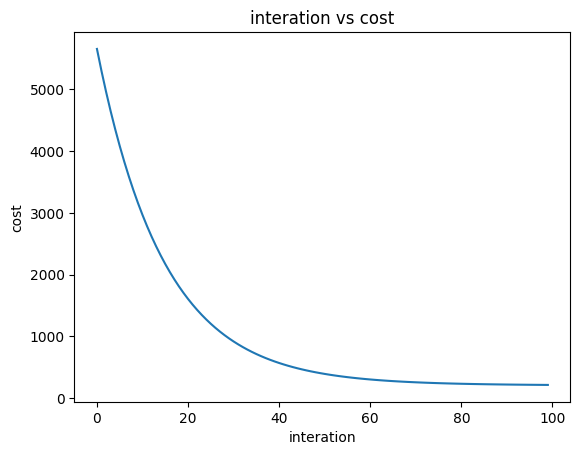

In [36]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(0, 100), c_hist[:100])
plt.title("interation vs cost")
plt.xlabel("interation")
plt.ylabel("cost")
plt.show()

In [32]:
print(f"最终w b =({w_final:.2f} {b_final:.2f})")

最终w b =(9.14 27.89)


In [33]:
print(f"年资3.5 预测薪水:{w_final*3.5 + b_final:.1f}K")


年资3.5 预测薪水:59.9K


In [37]:


ws = np.arange(-100, 101)
bs = np.arange(-100, 101)
costs = np.zeros((201, 201))

i = 0
for w in ws:
    j = 0
    for b in bs:
        cost = compute_cost(x, y, w, b)
        costs[i, j] = cost
        j += 1
    i += 1

In [38]:
!pip install wget

import wget
wget.download("https://github.com/GrandmaCan/ML/raw/main/Resgression/ChineseFont.ttf")


  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=4b9aff9f4b7a7081132014200da95934b4d1d63a14385848b311f8f1de97ab63
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


'ChineseFont.ttf'

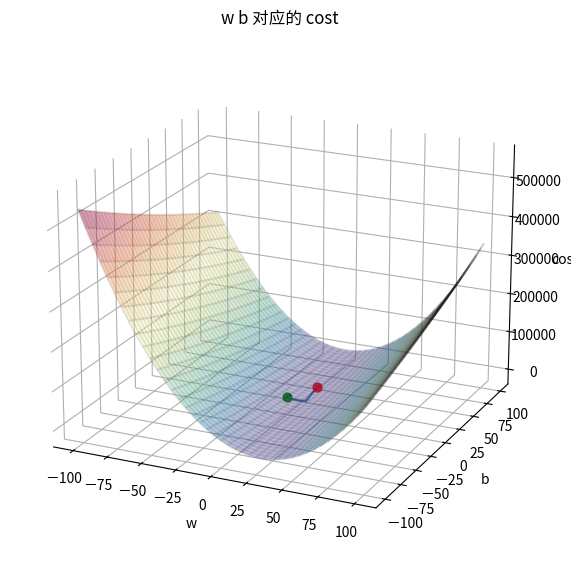

当w=[9], b=[29] 会有最小的cost：[32.69484848]


In [42]:
import matplotlib as mlp
from matplotlib.font_manager import fontManager
fontManager.addfont("ChineseFont.ttf")
mlp.rc('font', family = "ChineseFont")

plt.figure(figsize=(7, 7))

ax = plt.axes(projection = "3d")
ax.view_init(20, -65)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0))

b_grid, w_grid = np.meshgrid(bs, ws)
ax.plot_surface(w_grid, b_grid,costs, cmap="Spectral_r", alpha=0.4)
ax.plot_wireframe(w_grid, b_grid, costs, color = "black", alpha = 0.1)

ax.set_title("w b 对应的 cost")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("cost")

w_index, b_index = np.where(costs == np.min(costs))
ax.scatter(ws[w_index], bs[b_index], costs[w_index, b_index], color="red", s=40)
ax.scatter(w_hist[0], b_hist[0],c_hist[0],color = "green", s =40)
ax.plot(w_hist, b_hist, c_hist)

plt.show()

print(f"当w={ws[w_index]}, b={bs[b_index]} 会有最小的cost：{costs[w_index, b_index]}")